# Dataset : 

Link : https://www.kaggle.com/competitions/boston-housing/data

In [3]:
#!pip install seaborn

In [4]:
# Import pandas for tabular data loading and manipulation
# Import matplotlib for creating plots
# Import seaborn for statistical visualizations built on matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Uncomment this command to install the packages used in the notebook if needed
# !pip install pandas matplotlib seaborn

In [6]:
# Store the file paths for the training and test datasets
# These paths are reused when loading the CSV files
train_path = "boston-housing/train.csv"
test_path = "boston-housing/test.csv"

In [8]:
# Load the training CSV file into a pandas DataFrame
# The DataFrame stores rows as observations and columns as variables/features
train_df = pd.read_csv(train_path)

In [9]:
# Convert the DataFrame column index to a Python list
# This makes it easy to inspect the available feature and target names
train_df.columns.to_list()

['ID',
 'crim',
 'zn',
 'indus',
 'chas',
 'nox',
 'rm',
 'age',
 'dis',
 'rad',
 'tax',
 'ptratio',
 'black',
 'lstat',
 'medv']

In [10]:
# List the predictor columns used by the Boston housing model
# These variables describe crime, land use, accessibility, pollution, rooms, and other factors
FEATURE_COLUMNS = [
    'crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 
    'dis', 'rad', 'tax', 'ptratio', 'black', 'lstat'
]

# Part 1

In [11]:
# Preview the first five training rows to inspect values and column structure
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [12]:
# Inspect the number of rows and columns in the training dataset
# The tuple returned is (number of rows, number of columns)
train_df.shape

(333, 15)

In [15]:
# Define a reusable function for a quick dataset-quality summary
def basic_summary(df):
    # Count missing entries independently for every column
    print(f"Missing values : {df.isnull().sum()} \n\n")
    # Display each column's pandas data type
    print(f"Data DTypes : {df.dtypes} \n\n")
    # Calculate descriptive statistics, then transpose for one row per column
    print(f"Dataframe stats : {df.describe().T}")

In [16]:
# Run the reusable summary function on the training data
# This prints missing-value counts, data types, and descriptive statistics
basic_summary(train_df)

Missing values : ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64 


Data DTypes : ID           int64
crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
black      float64
lstat      float64
medv       float64
dtype: object 


Dataframe stats :          count        mean         std        min        25%        50%  \
ID       333.0  250.951952  147.859438    1.00000  123.00000  244.00000   
crim     333.0    3.360341    7.352272    0.00632    0.07896    0.26169   
zn       333.0   10.689189   22.674762    0.00000    0.00000    0.00000   
indus    333.0   11.293483    6.998123    0.74000    5.13000    9.90000   
chas     333.0    0.060060    0.237956    0.00000    0.00000   

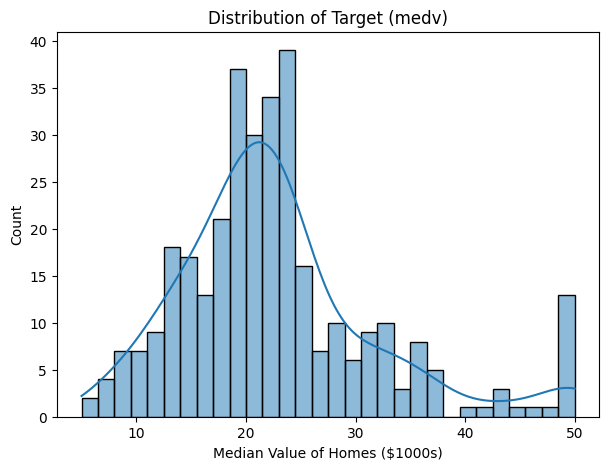

In [17]:
# Create a figure for the target-variable distribution
plt.figure(figsize=(7,5))
# Plot the medv target as a histogram and overlay a kernel-density estimate
# bins controls the number of histogram intervals; kde=True adds a smoothed curve
sns.histplot(train_df["medv"], kde=True, bins=30)
# Add descriptive labels to make the plot self-explanatory
plt.title("Distribution of Target (medv)")
plt.xlabel("Median Value of Homes ($1000s)")
plt.ylabel("Count")
# Render the completed chart
plt.show()

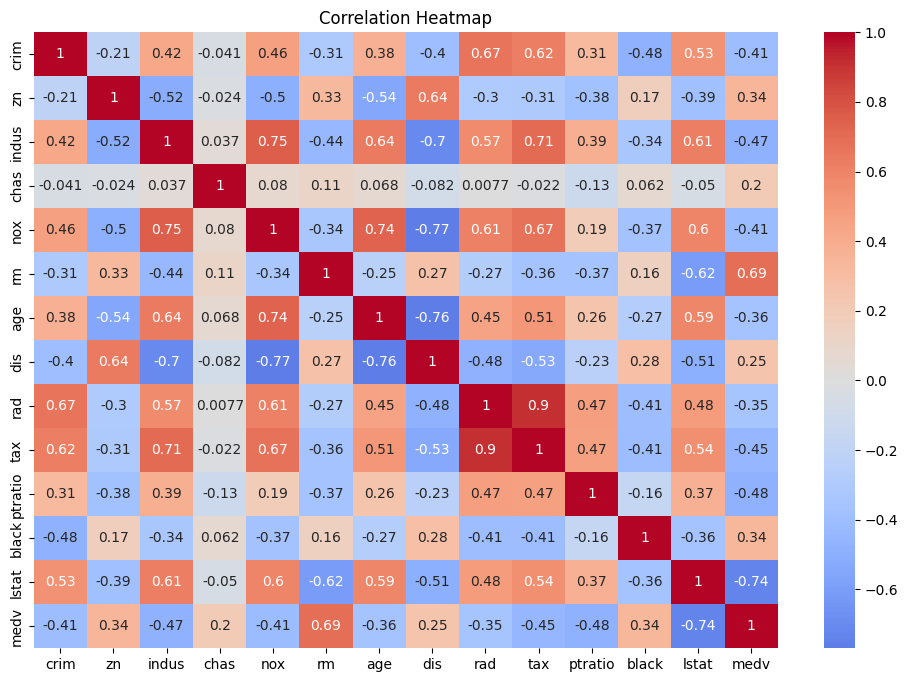

In [18]:
# Create a larger figure because the correlation matrix contains many variables
plt.figure(figsize=(12,8))
# Remove the ID column because it is an identifier rather than a meaningful predictor
# corr() calculates pairwise Pearson correlations among the remaining numeric columns
corr = train_df.drop(columns=["ID"]).corr()
# Display correlations as a color-coded matrix; annot=True writes values in each cell
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

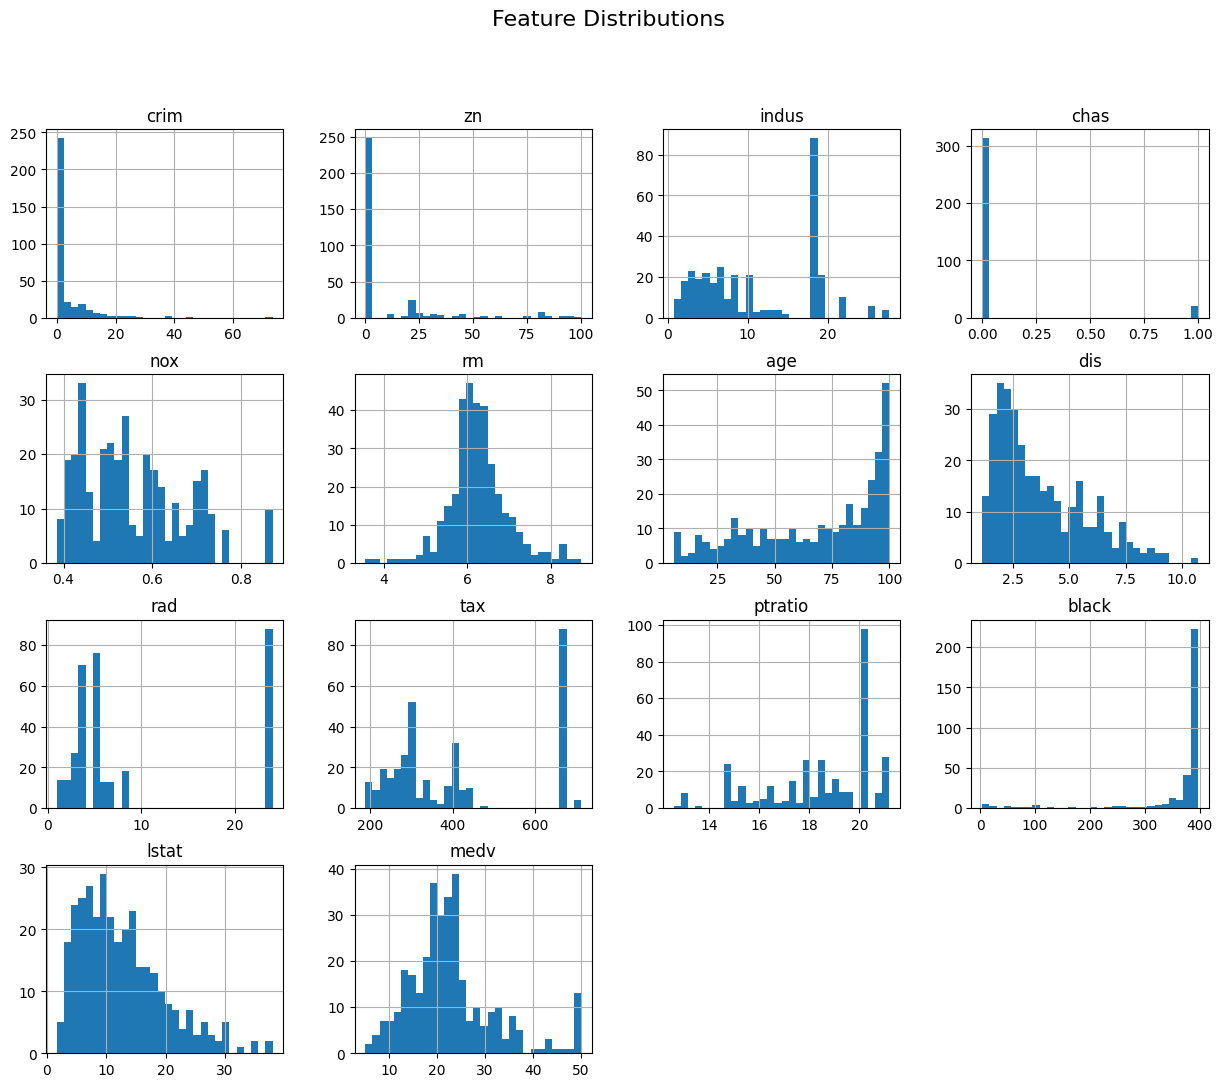

In [19]:
# Plot a histogram for every feature and the target variable
# The ID column is excluded because identifiers do not describe the data distribution
train_df.drop(columns=["ID"]).hist(figsize=(15,12), bins=30)
# Add one title above the collection of generated subplots
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

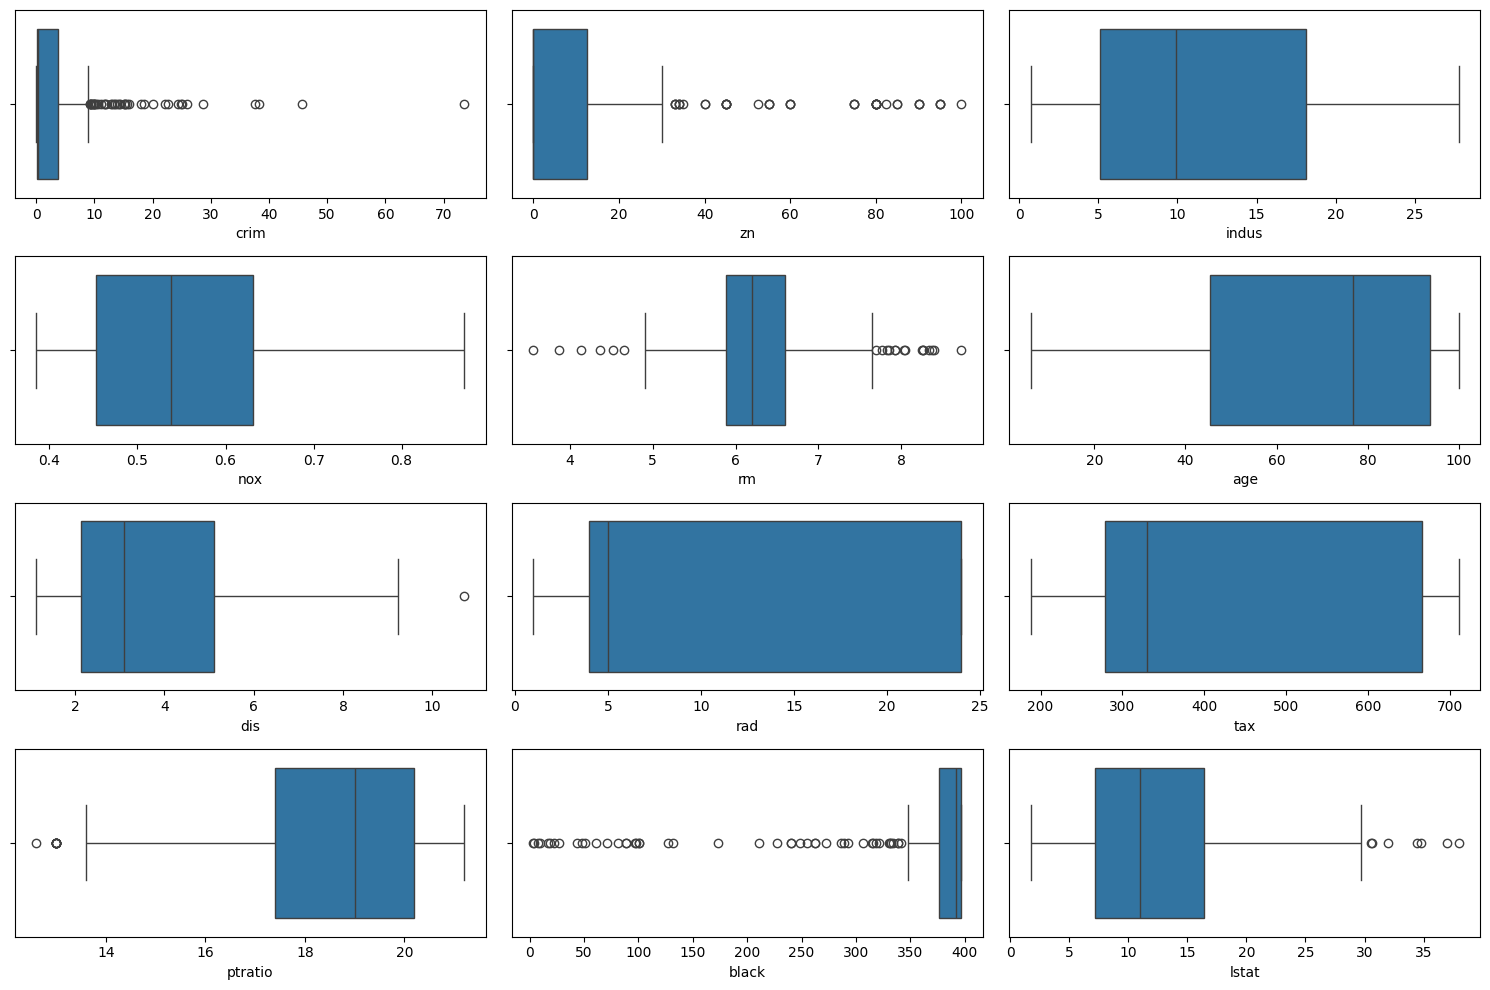

In [20]:
# Select continuous columns for outlier inspection
# Exclude ID, the binary chas column, and the target medv from these boxplots
numeric_cols = train_df.drop(columns=["ID", "chas", "medv"]).columns
plt.figure(figsize=(15,10))
# Create one boxplot per selected numeric feature
for i, col in enumerate(numeric_cols, 1):
    # Place each plot into a 4-by-3 grid; i is the subplot position
    plt.subplot(4, 3, i)
    # A boxplot shows the median, quartiles, and potential outliers for the feature
    sns.boxplot(x=train_df[col])
    # plt.title(col)
# Adjust spacing so the subplot collection does not overlap
plt.tight_layout()
plt.show()

# Part 2

In [25]:
# Import the function for creating train/test splits
from sklearn.model_selection import train_test_split
# Import ordinary least-squares and stochastic-gradient linear regression models
from sklearn.linear_model import LinearRegression, SGDRegressor 
# Linear regression by default uses ordinary least squares (OLS) to fit the model
# Import scaling and one-hot encoding transformations
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Import the tool that applies different transformations to selected columns
# For clean codng and doing multile type of encodng on separate columns in one go
from sklearn.compose import ColumnTransformer

In [26]:
# Uncomment this command to install scikit-learn if it is not already available
#!pip install scikit-learn

In [27]:
# Build the complete feature matrix by removing the identifier and target columns
# ID is excluded because it is only an identifier; medv is separated as it is the prediction target
X_train_full = train_df.drop(columns=["ID", "medv"])
# Store the median home value as the target series
# The model will learn to predict y_train_full from X_train_full
y_train_full = train_df['medv']

### We shall have a sizable data for test and validate too, otherwise the errors might look very different compared to train. The reason being, if train sees more data (more patterns) then it will try to find the model which works well for all patterns. 

### If the data in the test/validate is small and contains only a small subset of patterns compared to what is seen during training, obviously the model working on train data(more generic) will not yield good results on test/validate set with small amount of data only.

In [29]:
# Split features and targets into training and testing portions
# test_size=0.3 reserves 30% of the data for evaluation
# random_state makes the same rows selected each time the notebook runs
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_full, y_train_full,  test_size=0.3, random_state=20)

In [30]:
# Compare the number of rows in the full, training, and held-out subsets
print(X_train_full.shape[0])
print(X_train_split.shape[0])
print(X_test_split.shape[0])

333
233
100


In [32]:
# Identify continuous variables that should be standardized
numeric_features = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'tax', 'ptratio', 'black', 'lstat']
# Identify categorical/discrete variables that should be one-hot encoded
categorical_features = ['chas', 'rad']

In [33]:
# StandardScaler will center and scale each numeric feature
numeric_transformer = StandardScaler()
# OneHotEncoder converts categories to binary columns
# handle_unknown='ignore' prevents errors for unseen categories in test data
# drop='first' removes one category per variable to reduce redundant columns
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

In [34]:
# Build a preprocessing pipeline for different groups of columns
preprocessor = ColumnTransformer(
    transformers=[
        # Scale continuous columns using the numeric transformer which is defined above as standard scaler
        ('num', numeric_transformer, numeric_features),
        # One-hot encode categorical columns using the categorical transformer
        ('cat', categorical_transformer, categorical_features),
    ],
    # Keep any columns not listed above unchanged
    remainder='passthrough'
)

Imagine you are baking a cake using a recipe that needs to be converted from cups to grams.

- **`fit()`** is you **learning the rule**. You look at your specific batch of ingredients, measure how much one cup of flour weighs, and figure out the exact conversion number ($1 \text{ cup} = 120 \text{ grams}$). You haven't actually converted any flour yet; you just calculated and saved the rule.
- **`transform()`** is you **applying the rule**. You take your flour and use the number you calculated in the `fit` step to convert the cups into grams.
- **`fit_transform()`** is doing **both steps at once**. You look at the flour, calculate the conversion rule, and immediately convert it to grams in a single move.

### How to Use Them in Code

| Method | What It Does | When to Use It |
| --- | --- | --- |
| **`fit()`** | Calculates parameters (e.g., mean, standard deviation) from the data and saves them. | When you want to learn parameters from a dataset without changing it yet. |
| **`transform()`** | Applies the learned parameters to transform the data. | On **Test Data** or **New Data** (to avoid using test data to learn rules, which causes data leakage). |
| **`fit_transform()`** | Calculates parameters AND transforms the data in one step. | On **Training Data** only. |

### The Golden Rule to Avoid Bugs

Always use **`fit_transform()`** on your **training set** so your model learns the rules from it. Then, use **`transform()`** on your **test set** using those exact same rules. Never call `fit` or `fit_transform` on your test data!

In [35]:
# Learn preprocessing parameters from the training data and transform it
# fit_transform learns means, standard deviations, and category mappings before converting values
X_train_processed = preprocessor.fit_transform(X_train_split)
# Transform test data using the already-fitted training preprocessing
# Fitting again here would leak information from the test set into the model
X_test_processed = preprocessor.transform(X_test_split)

In [36]:
# Verify the dimensions after scaling and encoding
# The number of rows should match each split; the number of columns may increase after one-hot encoding
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

X_train_processed shape: (233, 20)
X_test_processed shape: (100, 20)


# Part 3

In [38]:
# Configure a linear regression model trained with stochastic gradient descent
# SGDRegressor updates coefficients using individual observations during optimization
sgd_reg = SGDRegressor(
    # Stop after at most 1000 passes if convergence has not occurred earlier (called epoch)
    max_iter=1000,
    # Set the initial learning rate used for coefficient updates
    eta0=0.01, # Learning rate,
    # Make the optimization results reproducible
    random_state=5
)

In [39]:
# Train the SGD linear regression model on preprocessed training features and targets
# fit learns the intercept and feature coefficients
sgd_reg.fit(X_train_processed, y_train_split) # both training data and target are used to learn the model parameters

,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",5
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1


In [40]:
# Inspect the learned coefficient for each processed feature
# These values represent each feature's contribution after preprocessing
sgd_reg.coef_

array([-0.38380188,  0.8683008 , -0.01083271, -1.22581814,  2.90165376,
        0.05159882, -2.91223521, -1.40392135, -1.88084274,  1.22698572,
       -4.64566683,  3.25025438,  0.40018433,  3.49131974,  1.63224267,
        1.7337928 , -0.21729018,  3.04064211,  3.2847097 ,  6.0140854 ])

In [41]:
# Inspect the learned intercept, or baseline prediction when processed features are zero
sgd_reg.intercept_

array([19.67239363])

In [42]:
# Configure an ordinary least-squares linear regression model
# Unlike SGDRegressor, LinearRegression solves the least-squares problem directly
linear_reg_ols = LinearRegression()

In [43]:
# Fit the ordinary least-squares model on the same processed training data
# This provides a second linear-regression implementation for comparison
linear_reg_ols.fit(X_train_processed, y_train_split)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[-0.42, 1.09, 0.28,..., 6.1 , 4.74, 6.66]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,18.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[37.44,16.65,15.55,..., 2.74, 2. , 0.87]"


# Test Model

In [44]:
# Generate predictions for the held-out test set using the trained SGD model
y_test_pred = sgd_reg.predict(X_test_processed)
# Generate predictions for the training set to evaluate fit on known data
y_train_pred = sgd_reg.predict(X_train_processed)

In [45]:
# Import mean squared error for measuring prediction error
# MSE averages the squared difference between actual and predicted target values
from sklearn.metrics import mean_squared_error

In [46]:
# Calculate mean squared error on the training predictions
# This measures how closely the model fits the data used for learning
mse_train = mean_squared_error(y_train_split, y_train_pred)
# Calculate mean squared error on unseen test predictions
# Comparing this with training MSE helps identify poor generalization
mse_test = mean_squared_error(y_test_split, y_test_pred)

# Display both metrics; lower MSE indicates smaller squared prediction errors
print(f"MSE (TRAIN) (SGD) : {mse_train}")
print(f"MSE (TEST) (SGD): {mse_test}")

MSE (TRAIN) (SGD) : 21.26978414072599
MSE (TEST) (SGD): 23.273431709637862


In [47]:
# Define a helper function for visually comparing actual and predicted values
def plot_actual_vs_predicted_lines(y_actual, y_predicted):
    # Create a wide figure so trends across the data index are easy to compare
    plt.figure(figsize=(14, 7))

    # Convert a pandas Series to a NumPy-like array for plotting when necessary
    if isinstance(y_actual, pd.Series):
        y_actual = y_actual.values
    
    # Plot the actual target values as a solid blue line
    plt.plot(y_actual, label='Actual Values', color='#1f77b4', linewidth=2)

    # Plot model predictions as a dashed orange line
    plt.plot(y_predicted, label='Predicted Values', color='#ff7f0e', linewidth=2, linestyle='--')
    
    # Add chart titles, axis labels, and a legend
    plt.title('Actual vs. Predicted Values Over Index (Trend Comparison)')
    plt.xlabel('Data Index')
    plt.ylabel('Median Home Value')
    plt.legend()
    # Add a light dotted grid to make line differences easier to read
    plt.grid(True, linestyle=':', alpha=0.6)
    # Prevent labels and the plot from being clipped
    plt.tight_layout()
    plt.show()

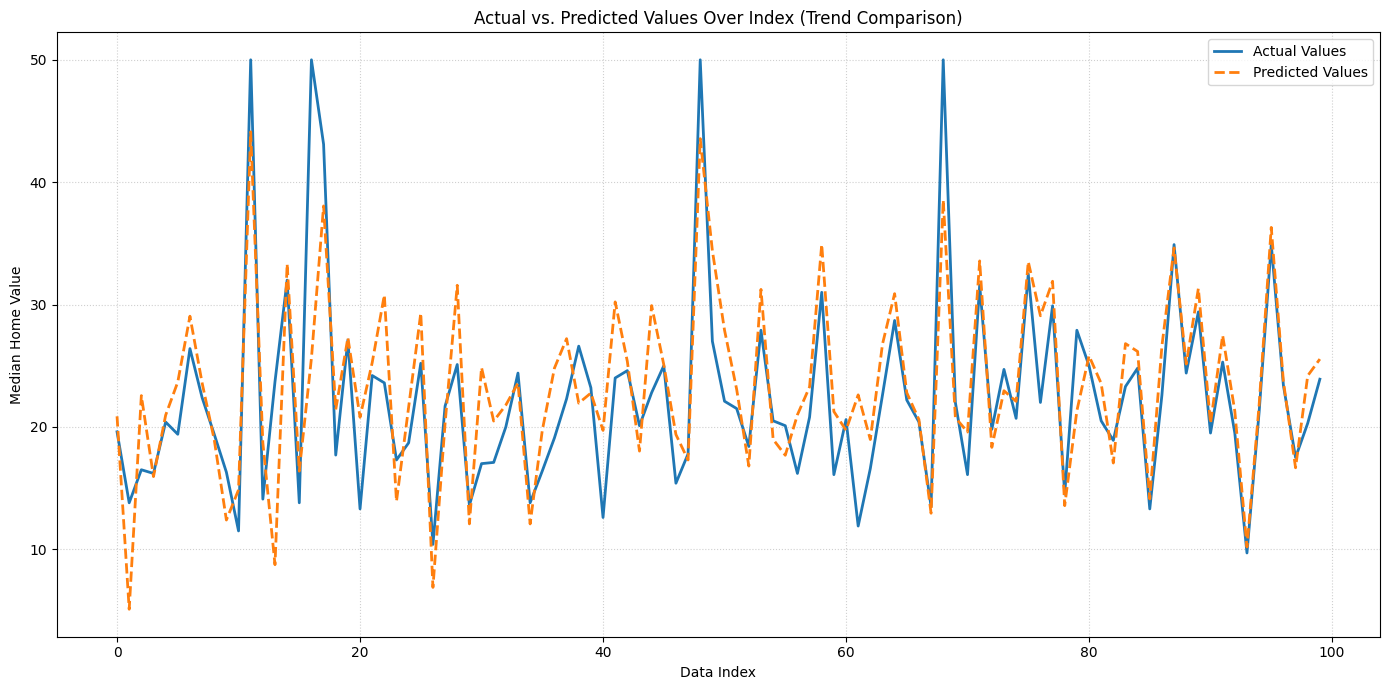

In [49]:
# Plot actual versus predicted home values for the held-out test set
# Close alignment between the two lines indicates better predictive performance
plot_actual_vs_predicted_lines(y_test_split, y_test_pred)

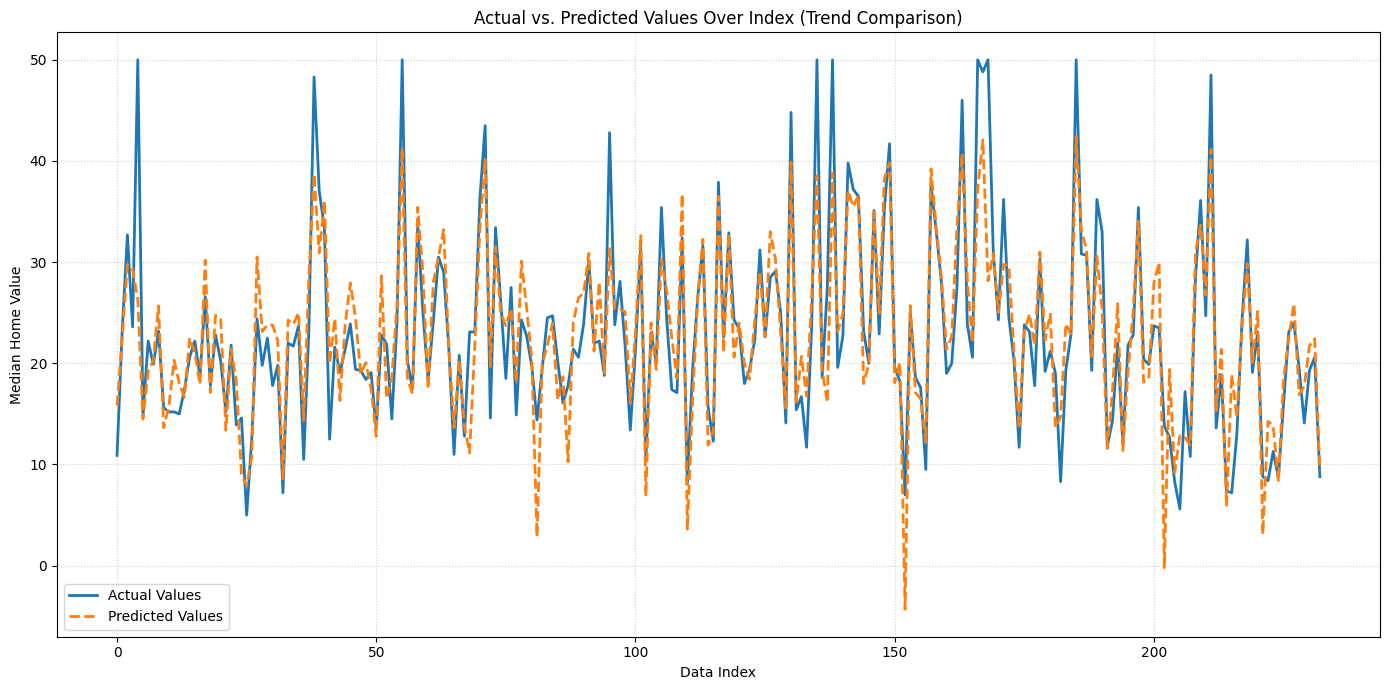

In [ ]:
# Do the train-set trend comparison for another visual inspection
plot_actual_vs_predicted_lines(y_train_split, y_train_pred)